In [1]:
%run 10_MNESIS_polychronous-chains.ipynb

datetag = '2026-04-21'
SNNtorch version 0.9.4
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps
Spikes in one target 1024.0,  in a SM window 42.0
for a value opt.lif_beta=0.7, the time constant is 2.8 steps


## defining traveling waves patterns

In [2]:
opt = Params()
hd = HD_SNN(opt)
hd.target.shape, opt, int(opt.N_neuron**.5)

(torch.Size([16, 1024, 1000]),
 Params(datetag='2026-04-21', N_neuron=1024, num_delay=41, N_SM=16, N_time=1000, N_pretime=50, p_A=0.001, seed=2018, lif_beta=0.7, learn_beta=False, learn_threshold=False, do_deconv=False, num_epochs=16, num_warmup_epochs=16, base_lr=0.001, final_lr=0.0001, delta1=0.01, delta2=5e-05, weight_decay=1e-09, init_gain=1.5, dropout=0.37, alpha_surrogate=15.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=15, fig_height=9, phi=1.61803, N_time_show=400, N_neuron_show=256, N_scan=5),
 32)

In [3]:
mc.random_cloud?

Object `mc.random_cloud` not found.


In [4]:
import MotionClouds as mc
def get_TW(angle):
    # define Fourier domain
    mc.N_X, mc.N_Y, mc.N_frame = int(opt.N_neuron**.5), int(opt.N_neuron**.5), opt.N_time//2
    fx, fy, ft = mc.get_grids(mc.N_X, mc.N_Y, mc.N_frame)
    # define an envelope
    envelope = mc.envelope_gabor(fx, fy, ft,
        V_X=np.cos(angle), V_Y=np.sin(angle), B_V=.1,
        sf_0=.10, B_sf=.05,
        theta=0., B_theta=np.pi/8
        )
    movie = mc.random_cloud(envelope, seed=opt.seed)
    movie = mc.rectif(movie)
    movie = (2*movie - 1)
    return torch.Tensor(movie)

movie = get_TW(angle=0.)
movie.min(), movie.max()

(tensor(-0.768), tensor(1.))

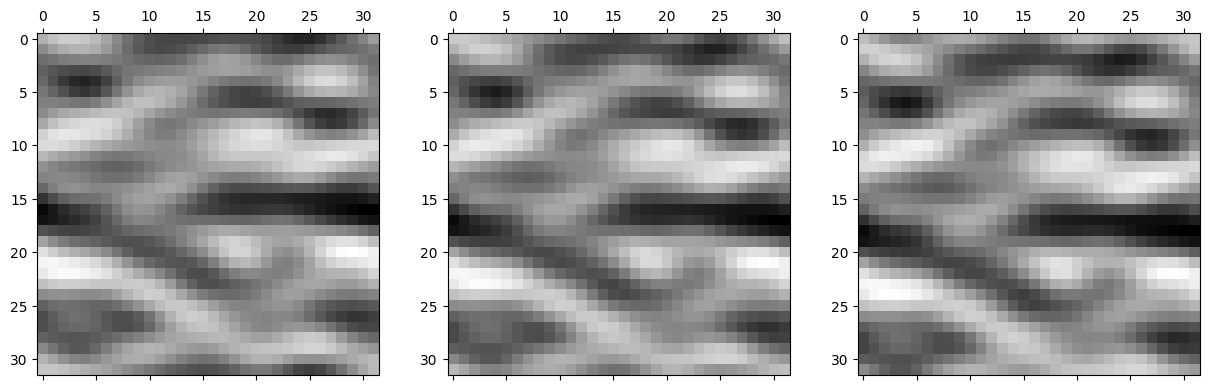

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(movie[:, :, i_ax], cmap='gray')

In [6]:
def get_TW_spike(angle, movie_gain=10., p_A=opt.p_A):
    movie = get_TW(angle)
    A_proba = torch.sigmoid(torch.logit(torch.tensor(p_A)) + movie_gain * movie) 
    return torch.bernoulli(A_proba)

A = get_TW_spike(angle=0.)
A.shape, A.mean()

(torch.Size([32, 32, 500]), tensor(0.008))

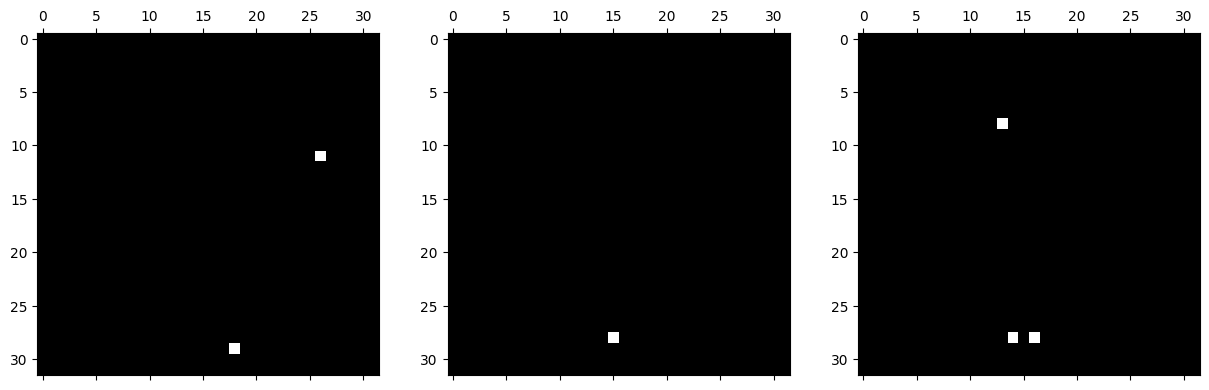

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(A[:, :, i_ax], cmap='gray')

In [8]:
if figpath is not None:
    import matplotlib.animation as animation

    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width))

    im = ax.imshow(A[:, :, 0], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')  # turn off axes

    def animate(frame):
        im.set_array(A[:, :, frame])
        ax.set_title(f"Frame {frame}")
        return [im]

    # ax.set_xlabel("X")
    # ax.set_ylabel("Y")

    anim = animation.FuncAnimation(
        fig,
        animate,
        frames=movie.shape[2],
        interval=40, # ms per frame
        blit=False,
        repeat=True
    )
    # Save as gif or mp4
    # anim.save(figpath / 'retrieval_animation.gif', writer='pillow', fps=20)
    anim.save(figpath / 'TW.mp4', writer='ffmpeg', fps=25)
    plt.close()

## learning traveling waves patterns patterns

In [9]:
opt = Params()
hd = HD_SNN(opt)
hd.net.to(hd.opt.device)

# Make the target periodic
for i_SM, angle in enumerate(np.linspace(0, 2*np.pi, opt.N_SM, endpoint=False)):
    TW = get_TW_spike(angle=angle).repeat(1, 1, 2)
    hd.target[i_SM, :, :] = TW.reshape((opt.N_neuron, opt.N_time))
hd.target.shape

torch.Size([16, 1024, 1000])

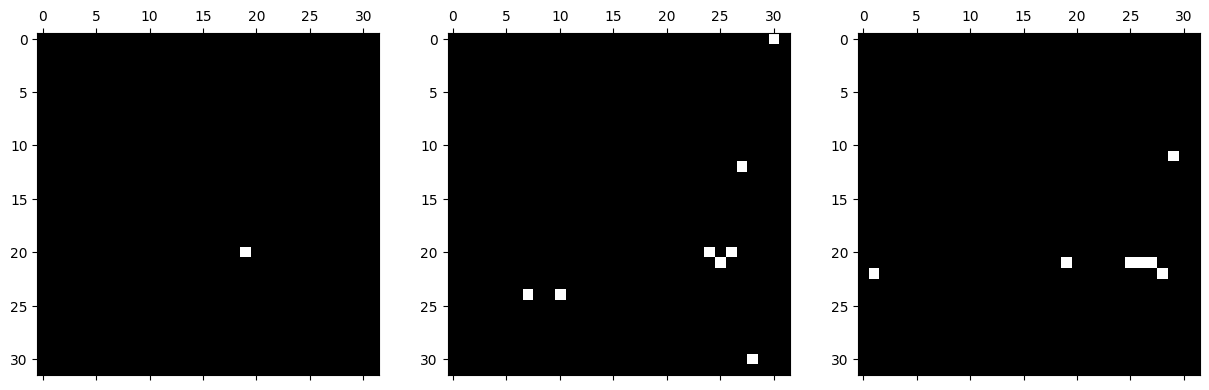

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(opt.fig_width, opt.fig_width/phi))
for i_ax, ax in enumerate(axs):
    ax.matshow(hd.target[i_SM, :,  i_ax].cpu().reshape((int(opt.N_neuron**.5), int(opt.N_neuron**.5))), cmap='gray')

In [11]:
model_filename = data_cache / f"{hd.opt.datetag}_TW.pth"
lock_filename = data_cache / model_filename.with_suffix('.lock')
# RECOMPUTE = True
if RECOMPUTE:
    model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_filename}, intitializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        hd.learn_model()
        ##################
        torch.save(hd.net.state_dict(), model_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model weights loaded from ../cached_data/2026-04-21_TW.pth


In [12]:
with torch.no_grad():
    target_full = torch.nn.functional.pad(hd.target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=hd.opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=hd.opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = hd.target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


(torch.Size([16, 1024, 1100]), 10120.0, 9974.0)

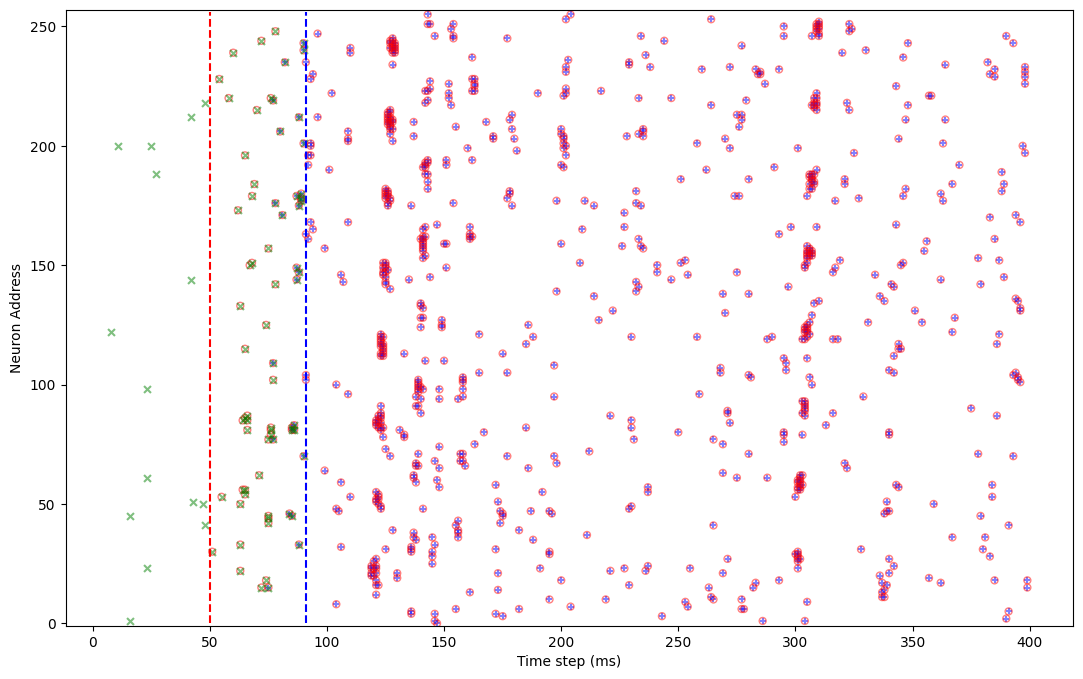

In [ ]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
if figpath is not None: printfig(fig, 'target', fig_width=opt.fig_width, fig_height=opt.fig_height)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()

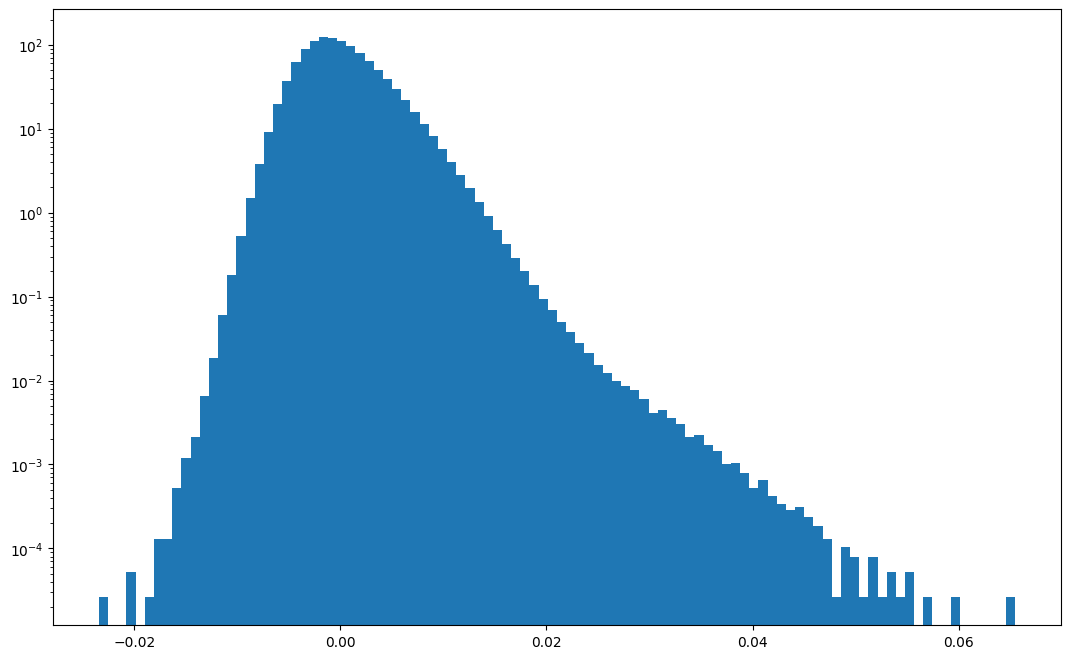

In [ ]:
# hd.net.lin.bias.cpu().detach().numpy()
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
ax.hist(hd.net.lin.weight.cpu().detach().numpy().ravel(), bins=100, density=True) # pyright: ignore[reportCallIssue, reportAttributeAccessIssue]
ax.set_yscale('log')

## spontaneuous state

In [21]:
N_repeat = 10

with torch.no_grad():
    # target_full = torch.nn.functional.pad(hd.target.repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    # input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*(opt.N_time-opt.num_delay)+2*opt.N_pretime)
    
    # input_spikes = flip_bits(input_spikes, .323)

    # _, _, spikes = hd.forward_pass(input_spikes)
    # spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    # target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]

    # precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    # print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

    # target_full = hd.target.repeat(1, 1, N_repeat)


    target_full = torch.nn.functional.pad(hd.target.repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(p_A=hd.opt.p_A, N_pretime=opt.N_pretime, N_trigger_time=hd.opt.num_delay, N_time=N_repeat*opt.N_time)
    _, _, spikes = hd.forward_pass(input_spikes)
    spikes_evoked = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    target_evoked = target_full[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(-hd.opt.N_pretime)]
    # spikes_evoked = spikes[:, :, hd.opt.num_delay:]
    # target_evoked = target_full[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

precision = 1.000	 recall = 1.000	 f1_score = 1.000 


In [20]:
target_full = torch.nn.functional.pad(hd.target.repeat(1, 1, N_repeat), (opt.N_pretime, opt.N_pretime))

hd.target.repeat(1, 1, N_repeat).shape, target_full.shape, opt.N_pretime, N_repeat*opt.N_time+2*opt.N_pretime


(torch.Size([16, 1024, 10000]), torch.Size([16, 1024, 10100]), 50, 10100)

In [ ]:
spikes_evoked.shape, target_evoked.shape, input_spikes.shape, spikes.shape, target_full.shape, opt.N_pretime

(torch.Size([16, 1024, 10100]), 99885.0, 9974.0)

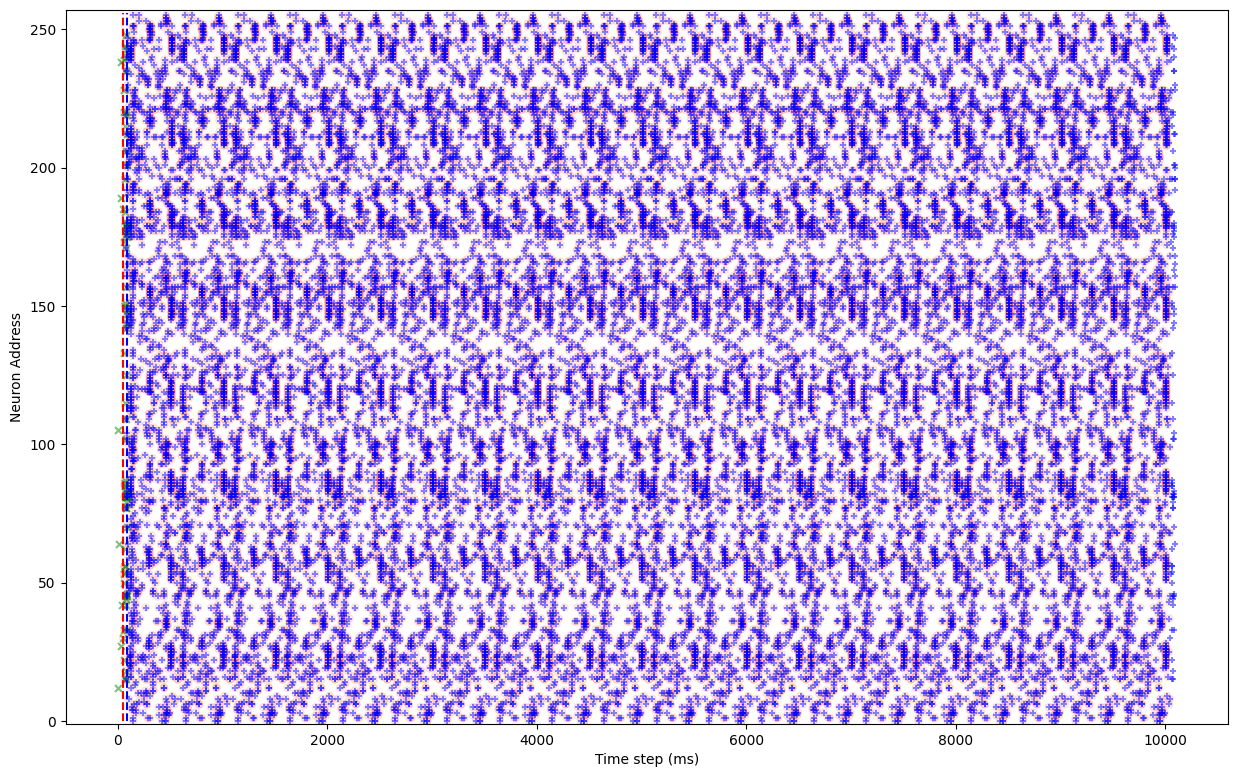

In [22]:
fig,ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
splt.raster(target_full[i_SM, :opt.N_neuron_show, :].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.15)
splt.raster(input_spikes[i_SM, :opt.N_neuron_show, :].T, ax, s=25, c="green", marker='x', alpha=.5)
splt.raster(spikes[i_SM, :opt.N_neuron_show, :].T, ax, s=25, c="blue", marker='+', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
spikes.shape, spikes[i_SM, :, :].sum().item(), hd.target[i_SM, :, :].sum().item()